In [1]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
subset = df[df.datasets == 'mnfinder_validation']
subset.filenames.to_list()[0]

'2022-05-26_RPE1-2198.tif'

In [3]:
df.datasets.unique()

array(['DinoMN_data_02', 'DinoMN_data_01', 'mnfinder_train',
       'mnfinder_test', 'mnfinder_validation', 'BBBC039'], dtype=object)

- screen

In [4]:
path = '/scr/yren/annotated_mn_datasets/validation/'
screen_path = path + 'images/C2-20X_c0-DAPI-GFP_A2_Tile-5.tif'
screen_gt_path = path + 'mn_masks/C2-20X_c0-DAPI-GFP_A2_Tile-5.png'
dinomn_path = '/mnt/cephfs/mir/jcaicedo/projects/micronuclei_detection/Train_and_Eval/dinomn_data/figures/dinomn_figures/figure4/dinomn_predictions/C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy'

input_screen = skimage.io.imread(screen_path)
gt_screen = skimage.io.imread(screen_gt_path)
nuclei_gt_screen = skimage.io.imread(screen_path.replace('images','nuclei_masks'))
dinomn_screen = np.load(dinomn_path)
mnfinder_screen = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_screen = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_screen = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

- BBBC039

In [5]:
imid = 'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1'
bbbc039_path = path + f'images/{imid}.tif'
bbbc039_gt_path = path + f'mn_masks/{imid}.png'
dinomn_path = f'/mnt/cephfs/mir/jcaicedo/projects/micronuclei_detection/Train_and_Eval/dinomn_data/figures/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_bbbc039 = skimage.io.imread(bbbc039_path)
gt_bbbc039 = skimage.io.imread(bbbc039_gt_path)
nuclei_gt_bbbc039 = skimage.io.imread(bbbc039_path.replace('images','nuclei_masks'))
dinomn_bbbc039 = np.load(dinomn_path)
mnfinder_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

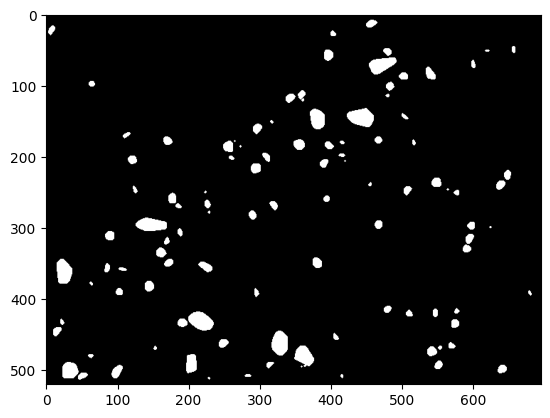

In [6]:
plt.imshow(mnfinder_bbbc039 > 0, cmap='gray')

- HeLa & RPE1

In [7]:
imid = 'C1-20X_c0_B3_Tile-24'
hela_rpe1_path = path + f'images/{imid}.tif'
hela_rpe1_gt_path = path + f'mn_masks/{imid}.png'
dinomn_path = f'/mnt/cephfs/mir/jcaicedo/projects/micronuclei_detection/Train_and_Eval/dinomn_data/figures/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_hela_rpe1 = skimage.io.imread(hela_rpe1_path)
gt_hela_rpe1 = skimage.io.imread(hela_rpe1_gt_path)
nuclei_gt_hela_rpe1 = skimage.io.imread(hela_rpe1_path.replace('images','nuclei_masks'))
dinomn_hela_rpe1 = np.load(dinomn_path)
mnfinder_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

- MNFinder Data

In [8]:
imid = '2022-05-26_RPE1-2198'
mnfinder_path = path + f'images/{imid}.tif'
mnfinder_gt_path = path + f'mn_masks/{imid}.png'
dinomn_path = f'/mnt/cephfs/mir/jcaicedo/projects/micronuclei_detection/Train_and_Eval/dinomn_data/figures/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_mnfinder = skimage.io.imread(mnfinder_path)
gt_mnfinder = skimage.io.imread(mnfinder_gt_path)
nuclei_gt_mnfinder = skimage.io.imread(mnfinder_path.replace('images','nuclei_masks'))
dinomn_mnfinder = np.load(dinomn_path)
mnfinder_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

# Grid Plot

# Add the nuclei mask first, remember to be gray not white

In [9]:
inputs = [input_screen, input_bbbc039, input_hela_rpe1, input_mnfinder]
gt = [gt_screen, gt_bbbc039, gt_hela_rpe1, gt_mnfinder]
gt_nuclei = [nuclei_gt_screen, nuclei_gt_bbbc039, nuclei_gt_hela_rpe1, nuclei_gt_mnfinder]
dinomn = [dinomn_screen, dinomn_bbbc039, dinomn_hela_rpe1, dinomn_mnfinder]
mnfinder = [mnfinder_screen, mnfinder_bbbc039, mnfinder_hela_rpe1, mnfinder_mnfinder]
cellpose = [cellpose_screen, cellpose_bbbc039, cellpose_hela_rpe1, cellpose_mnfinder]
microsam = [microsam_screen, microsam_bbbc039, microsam_hela_rpe1, microsam_mnfinder]

In [10]:
dinomn_2 = []
for i in range(len(gt_nuclei)):
    H, W = dinomn[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (dinomn[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]

    # Step 2: add overlap (yellow)
    im[overlap] = [255, 255, 0]

    # Step 3: prediction only (red)
    im[pred_only] = [255, 0, 0]

    # Step 4: ground truth only (green)
    im[gt_only] = [0, 255, 0]

    dinomn_2.append(im)


In [11]:
gt_2 = []
for i in range(len(gt_nuclei)):
    H, W = gt[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    nuclei_mask = (gt_nuclei[i] > 0)
    gt_mask     = (gt[i] > 0)

    im[nuclei_mask] = [128, 128, 128]
    im[gt_mask] = [238, 130, 238] # color: violet

    gt_2.append(im)


In [12]:
mnfinder_2 = []
for i in range(len(gt_nuclei)):
    H, W = mnfinder[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (mnfinder[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [255, 255, 0]
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [0, 255, 0]

    mnfinder_2.append(im)


In [13]:
cellpose_2 = []
for i in range(len(gt_nuclei)):
    H, W = cellpose[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (cellpose[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [255, 255, 0]
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [0, 255, 0]

    cellpose_2.append(im)


In [14]:
microsam_2 = []
for i in range(len(gt_nuclei)):
    H, W = microsam[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (microsam[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [255, 255, 0]
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [0, 255, 0]

    microsam_2.append(im)


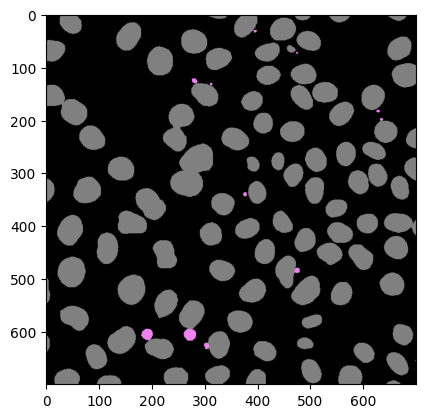

In [15]:
plt.imshow(gt_2[0][2100:2100+700, 1300:1300+700, :], cmap='gray')

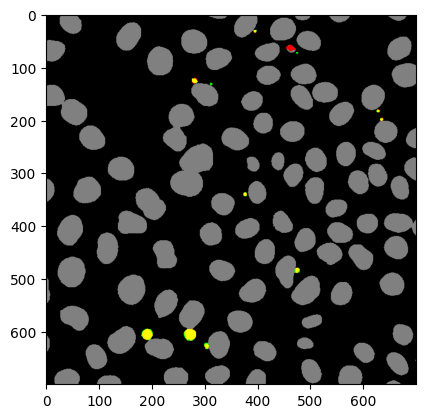

In [16]:
plt.imshow(dinomn_2[0][2100:2100+700, 1300:1300+700,:] )

In [17]:
collections = [inputs, gt_2, dinomn_2, mnfinder_2, cellpose_2, microsam_2]

In [18]:
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

- Prepare scale bar

In [19]:
df.datasets.unique()

array(['DinoMN_data_02', 'DinoMN_data_01', 'mnfinder_train',
       'mnfinder_test', 'mnfinder_validation', 'BBBC039'], dtype=object)

In [20]:
df[df.datasets == 'mnfinder_validation'].micron

70    11.0
71    11.0
72    11.0
Name: micron, dtype: float64

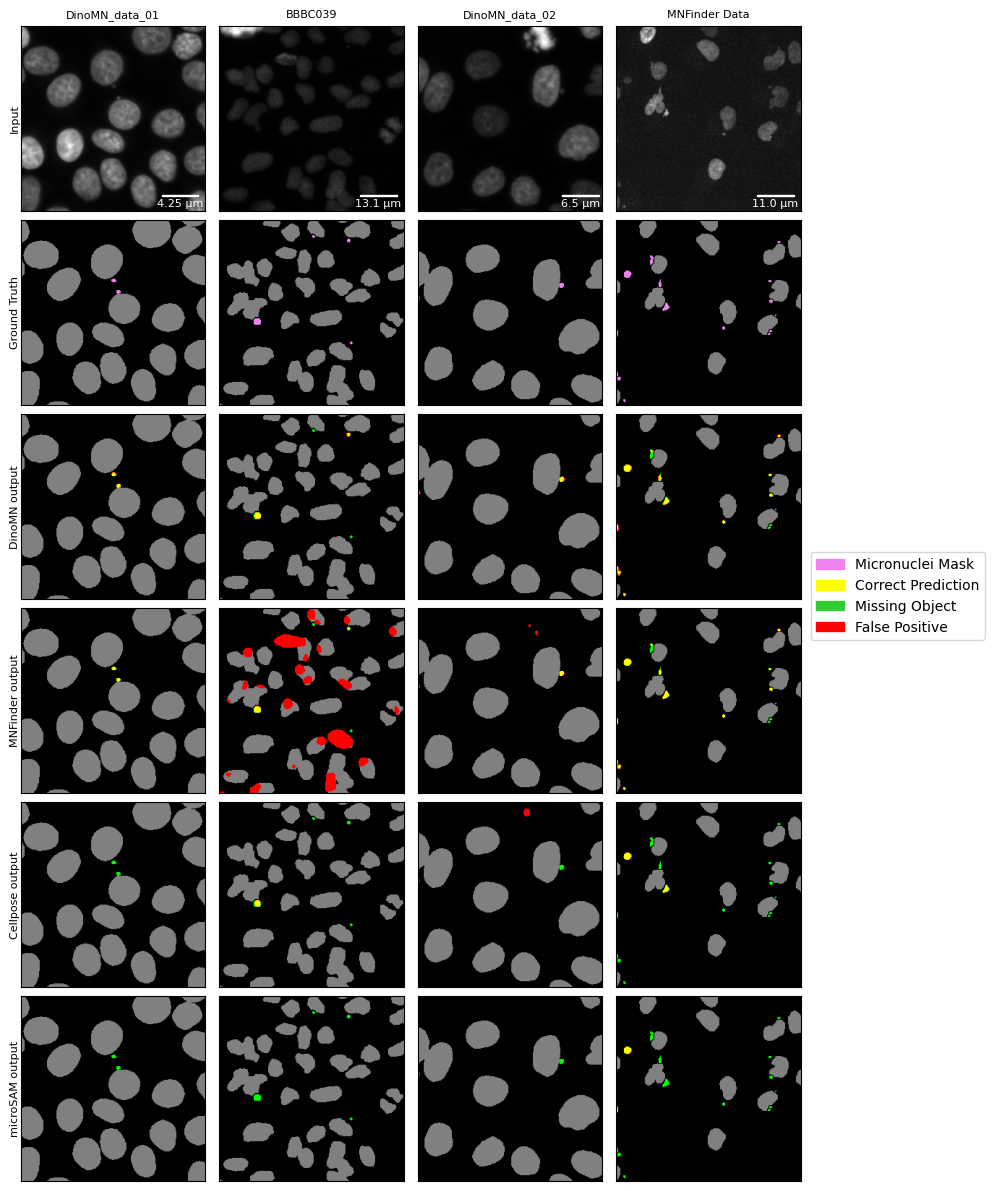

In [24]:
fig, ax = plt.subplots(6,4, figsize=(15,15))
fontprops = fm.FontProperties(size=8)
plt.subplots_adjust(wspace=-0.65, hspace=0.05)

legend_elements = [mpatches.Patch(color='violet', label='Micronuclei Mask'),
                   mpatches.Patch(color='yellow', label='Correct Prediction'),
                   mpatches.Patch(color='limegreen', label='Missing Object'),
                   mpatches.Patch(color='red', label='False Positive')]

# Add the legend to the plot
fig.legend(handles=legend_elements, loc='right', bbox_to_anchor=(0.9, 0.5))
    
# Labels for columns and rows
microns = [4.25, 13.1, 6.5, 11.0]
col_labels = ['DinoMN_data_01', 'BBBC039', 'DinoMN_data_02', 'MNFinder Data']
row_labels = ['Input', 'Ground Truth', 'DinoMN output', 'MNFinder output', 'Cellpose output', 'microSAM output']

for i in range(6):
    for j in range(4):
        if j==0: # Pilot Screen
            r,c = 2200,1800
        elif j == 1: # BBBC039
            r,c = 250,50
        elif j==2: # HeLa RPE1
            r,c = 1700,2000
        elif j==3: # MNFinder
            r,c = 150,300
        if i == 0:
            PS=256
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS], cmap='gray')
        else:
            PS=256
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS,:])

        # Hide ticks but keep labels
        ax[i, j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if i == 0:
            ax[i, j].set_title(col_labels[j], fontsize=8)
            # add scalebar
            scalebar = AnchoredSizeBar(transform=ax[i,j].transData,
                            size=50, 
                            label=f'{microns[j]} µm', 
                            loc='lower right', 
                            pad=0.1,
                            color='white',
                            frameon=False,
                            size_vertical=1,
                            fontproperties=fontprops)
            ax[i, j].add_artist(scalebar)
            

        # Set row labels on the left side
        if j == 0:
            # ax[i, j].set_ylabel(row_labels[i], fontsize=10, rotation=0, labelpad=30, va='center')
            ax[i, j].set_ylabel(row_labels[i], fontsize=8, rotation=90, va='center')


plt.show()

In [ ]:
plt.savefig('/scr/yren/dinomn_figure4.png', transparent=True)

<Figure size 640x480 with 0 Axes>